In [5]:
import pandas as pd

# Load the tables
order_details = pd.read_csv("northwind_order_details.csv")
orders = pd.read_csv("northwind_orders.csv")


In [6]:
print("Orders table:")
print(orders.head())

print("\nOrder Details table:")
print(order_details.head())

Orders table:
   order_id customer_id  employee_id  order_date required_date shipped_date  \
0     10248       VINET            5  1996-07-04    1996-08-01   1996-07-16   
1     10249       TOMSP            6  1996-07-05    1996-08-16   1996-07-10   
2     10250       HANAR            4  1996-07-08    1996-08-05   1996-07-12   
3     10251       VICTE            3  1996-07-08    1996-08-05   1996-07-15   
4     10252       SUPRD            4  1996-07-09    1996-08-06   1996-07-11   

   ship_via  freight                  ship_name          ship_address  \
0         3    32.38  Vins et alcools Chevalier    59 rue de l'Abbaye   
1         1    11.61         Toms Spezialitäten         Luisenstr. 48   
2         2    65.83              Hanari Carnes       Rua do Paço, 67   
3         1    41.34       Victuailles en stock    2, rue du Commerce   
4         2    51.30           Suprêmes délices  Boulevard Tirou, 255   

        ship_city ship_region ship_postal_code ship_country  
0         

In [7]:
# Remove duplicates
orders.drop_duplicates(inplace=True)
order_details.drop_duplicates(inplace=True)

# Check for missing values
print("Orders missing values:\n", orders.isnull().sum())
print("\nOrder Details missing values:\n", order_details.isnull().sum())

Orders missing values:
 order_id              0
customer_id           0
employee_id           0
order_date            0
required_date         0
shipped_date         21
ship_via              0
freight               0
ship_name             0
ship_address          0
ship_city             0
ship_region         507
ship_postal_code     19
ship_country          0
dtype: int64

Order Details missing values:
 order_id      0
product_id    0
unit_price    0
quantity      0
discount      0
dtype: int64


In [9]:
merged_data = order_details.merge(orders, on='order_id', how='left')
merged_data.head()

,order_id,product_id,unit_price,quantity,discount,customer_id,employee_id,order_date,required_date,shipped_date,ship_via,freight,ship_name,ship_address,ship_city,ship_region,ship_postal_code,ship_country
0,10248,11,14.0,12,0.0,VINET,5,1996-07-04,1996-08-01,1996-07-16,3,32.38,Vins et alcools Chevalier,59 rue de l'Abbaye,Reims,NaN,51100,France
1,10248,42,9.8,10,0.0,VINET,5,1996-07-04,1996-08-01,1996-07-16,3,32.38,Vins et alcools Chevalier,59 rue de l'Abbaye,Reims,NaN,51100,France
2,10248,72,34.8,5,0.0,VINET,5,1996-07-04,1996-08-01,1996-07-16,3,32.38,Vins et alcools Chevalier,59 rue de l'Abbaye,Reims,NaN,51100,France
3,10249,14,18.6,9,0.0,TOMSP,6,1996-07-05,1996-08-16,1996-07-10,1,11.61,Toms Spezialitäten,Luisenstr. 48,Münster,NaN,44087,Germany
4,10249,51,42.4,40,0.0,TOMSP,6,1996-07-05,1996-08-16,1996-07-10,1,11.61,Toms Spezialitäten,Luisenstr. 48,Münster,NaN,44087,Germany


In [11]:
merged_data[['shipped_date', 'ship_region', 'ship_postal_code']].isnull().sum()

shipped_date          73
ship_region         1299
ship_postal_code      55
dtype: int64

In [15]:
merged_data['ship_region'] = merged_data['ship_region'].fillna("Unknown")
merged_data['ship_postal_code'] = merged_data['ship_postal_code'].fillna("Unknown")

In [16]:
merged_data[['shipped_date', 'ship_region', 'ship_postal_code']].isnull().sum()

shipped_date        73
ship_region          0
ship_postal_code     0
dtype: int64

In [21]:
import pandas as pd

# Make sure order_date and ship_date are datetime
merged_data['order_date'] = pd.to_datetime(merged_data['order_date'], errors='coerce')
merged_data['shipped_date'] = pd.to_datetime(merged_data['shipped_date'], errors='coerce')

print(merged_data['shipped_date'])

0      1996-07-16
1      1996-07-16
2      1996-07-16
3      1996-07-10
4      1996-07-10
          ...    
2150          NaT
2151          NaT
2152          NaT
2153          NaT
2154          NaT
Name: shipped_date, Length: 2155, dtype: datetime64[ns]


In [22]:
# Only consider rows where ship_date is not missing
shipping_days = (merged_data['shipped_date'] - merged_data['order_date']).dt.days

# Average shipping days
avg_shipping_days = int(shipping_days.mean())
print("Average Shipping Days:", avg_shipping_days)

Average Shipping Days: 8


In [23]:
# Fill missing ship_date with order_date + average shipping days
merged_data['shipped_date'] = merged_data.apply(
    lambda row: row['order_date'] + pd.Timedelta(days=avg_shipping_days)
    if pd.isna(row['shipped_date']) else row['shipped_date'],
    axis=1
)

In [26]:
# Check that no ship_date is missing
print(merged_data['shipped_date'].isnull().sum())
merged_data[['order_date', 'shipped_date']].head(10)

0


,order_date,shipped_date
0,1996-07-04,1996-07-16
1,1996-07-04,1996-07-16
2,1996-07-04,1996-07-16
3,1996-07-05,1996-07-10
4,1996-07-05,1996-07-10
5,1996-07-08,1996-07-12
6,1996-07-08,1996-07-12
7,1996-07-08,1996-07-12
8,1996-07-08,1996-07-15
9,1996-07-08,1996-07-15


In [27]:
# Revenue per line item
order_details['Revenue'] = order_details['unit_price'] * order_details['quantity']
order_details.head()

,order_id,product_id,unit_price,quantity,discount,Revenue
0,10248,11,14.0,12,0.0,168.0
1,10248,42,9.8,10,0.0,98.0
2,10248,72,34.8,5,0.0,174.0
3,10249,14,18.6,9,0.0,167.4
4,10249,51,42.4,40,0.0,1696.0


In [29]:
merged_data = order_details.merge(orders, on='order_id', how='left')
merged_data.head()

,order_id,product_id,unit_price,quantity,discount,Revenue,customer_id,employee_id,order_date,required_date,shipped_date,ship_via,freight,ship_name,ship_address,ship_city,ship_region,ship_postal_code,ship_country
0,10248,11,14.0,12,0.0,168.0,VINET,5,1996-07-04,1996-08-01,1996-07-16,3,32.38,Vins et alcools Chevalier,59 rue de l'Abbaye,Reims,NaN,51100,France
1,10248,42,9.8,10,0.0,98.0,VINET,5,1996-07-04,1996-08-01,1996-07-16,3,32.38,Vins et alcools Chevalier,59 rue de l'Abbaye,Reims,NaN,51100,France
2,10248,72,34.8,5,0.0,174.0,VINET,5,1996-07-04,1996-08-01,1996-07-16,3,32.38,Vins et alcools Chevalier,59 rue de l'Abbaye,Reims,NaN,51100,France
3,10249,14,18.6,9,0.0,167.4,TOMSP,6,1996-07-05,1996-08-16,1996-07-10,1,11.61,Toms Spezialitäten,Luisenstr. 48,Münster,NaN,44087,Germany
4,10249,51,42.4,40,0.0,1696.0,TOMSP,6,1996-07-05,1996-08-16,1996-07-10,1,11.61,Toms Spezialitäten,Luisenstr. 48,Münster,NaN,44087,Germany


In [32]:
order_revenue = merged_data.groupby('order_id')['Revenue'].sum()
print(order_revenue.head(10))

order_id
10248     440.0
10249    1863.4
10250    1813.0
10251     670.8
10252    3730.0
10253    1444.8
10254     625.2
10255    2490.5
10256     517.8
10257    1119.9
Name: Revenue, dtype: float64


In [31]:
avg_order_value = merged_data.groupby('order_id')['Revenue'].sum().mean()
print("Average Order Value:", round(avg_order_value, 2))

Average Order Value: 1631.88


In [33]:
top_customers = merged_data.groupby('customer_id')['Revenue'].sum().sort_values(ascending=False)
print(top_customers.head(10))

customer_id
QUICK    117483.39
SAVEA    115673.39
ERNSH    113236.68
HUNGO     57317.39
RATTC     52245.90
HANAR     34101.15
FOLKO     32555.55
MEREP     32203.90
KOENE     31745.75
QUEEN     30226.10
Name: Revenue, dtype: float64


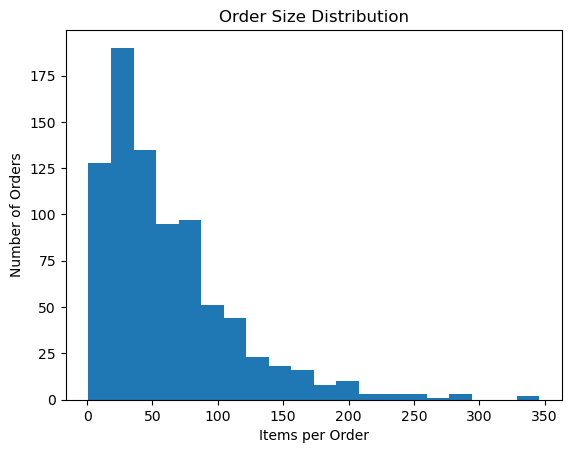

In [35]:
import matplotlib.pyplot as plt

order_sizes = merged_data.groupby('order_id')['quantity'].sum()
plt.hist(order_sizes, bins=20)
plt.xlabel("Items per Order")
plt.ylabel("Number of Orders")
plt.title("Order Size Distribution")
plt.show()

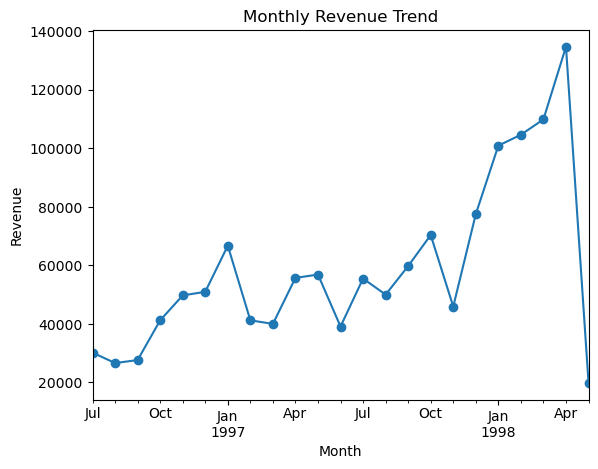

In [37]:
# Convert order_date to datetime
merged_data['order_date'] = pd.to_datetime(merged_data['order_date'])

# Extract month
merged_data['month'] = merged_data['order_date'].dt.to_period('M')

# Revenue per month
monthly_revenue = merged_data.groupby('month')['Revenue'].sum()
monthly_revenue.plot(kind='line', marker='o', title='Monthly Revenue Trend')
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

In [38]:
# Save the DataFrame to CSV
merged_data.to_csv("northwind_cleaned.csv", index=False)

In [39]:
# Read back to check
df_check = pd.read_csv("northwind_cleaned.csv")
print(df_check.head())

   order_id  product_id  unit_price  quantity  discount  Revenue customer_id  \
0     10248          11        14.0        12       0.0    168.0       VINET   
1     10248          42         9.8        10       0.0     98.0       VINET   
2     10248          72        34.8         5       0.0    174.0       VINET   
3     10249          14        18.6         9       0.0    167.4       TOMSP   
4     10249          51        42.4        40       0.0   1696.0       TOMSP   

   employee_id  order_date required_date shipped_date  ship_via  freight  \
0            5  1996-07-04    1996-08-01   1996-07-16         3    32.38   
1            5  1996-07-04    1996-08-01   1996-07-16         3    32.38   
2            5  1996-07-04    1996-08-01   1996-07-16         3    32.38   
3            6  1996-07-05    1996-08-16   1996-07-10         1    11.61   
4            6  1996-07-05    1996-08-16   1996-07-10         1    11.61   

                   ship_name        ship_address ship_city shi